# GWPS boundary tracking — EI acquisition

`random` = joint intervention on a random NON-parent set (new set per seed); the kernel variants intervene jointly on the 8 true parents. 60-node GWPS subgraph, `weight_scale=3`, 5 seeds.


In [31]:
import os, pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT = ".."                      # notebook lives in notebooks/
EDGE = 0.20                      # outer-20% edge zone
RUNS_TO_TRY = [1, 2, 3, 4, 5]    # replicate seeds are encoded as run numbers
FN_TMPL = "run{run}_cbo_unknown_dr2_boundary_EI_200_1.pickle"
GRAPHS = ["gwps_n60_ws3"]

VARIANTS = {
    "Non-Parent Interv.":           "results/boundary_tracking_gwps_random",
    "Parent Interv. RBF":              "results/boundary_tracking_gwps_oracle",
    "Parent Interv. spherical linear": "results/boundary_tracking_gwps_oracle_spherical",
    "Parent Interv. spherical RBF":    "results/boundary_tracking_gwps_oracle_spherical_rbf",
}
COLORS = {"Non-Parent Interv.": "#D55E00", "Parent Interv. RBF": "#0072B2",
          "Parent Interv. spherical linear": "#009E73", "Parent Interv. spherical RBF": "#CC79A7"}

def load_runs(variant, graph):
    """All available replicates -> list of (run_num, result)."""
    out = []
    for run in RUNS_TO_TRY:
        p = os.path.join(ROOT, VARIANTS[variant], graph, FN_TMPL.format(run=run))
        if os.path.exists(p):
            with open(p, "rb") as f:
                out.append((run, pickle.load(f)))
    return out

def per_intervention(r):
    """One row per intervened DIMENSION (interventions are joint: |set| rows/trial)."""
    rng, tp = r["Intervention_Ranges"], set(r["True_Parents"])
    rows = []
    for t, (vs, vals) in enumerate(zip(r["Intervention_Set"], r["Intervention_Value"])):
        for var, val in zip(vs, vals):
            lo, hi = rng[var]
            val = float(val)
            rows.append(dict(trial=t, var=var, value=val,
                             pos=(val - lo) / (hi - lo) if hi > lo else np.nan,
                             is_parent=var in tp))
    return pd.DataFrame(rows)

RUNS = {(v, g): load_runs(v, g) for v in VARIANTS for g in GRAPHS}
print({f"{v}|{g}": f"{len(rs)} run(s)" for (v, g), rs in RUNS.items()})

{'Non-Parent Interv.|gwps_n60_ws3': '5 run(s)', 'Parent Interv. RBF|gwps_n60_ws3': '5 run(s)', 'Parent Interv. spherical linear|gwps_n60_ws3': '5 run(s)', 'Parent Interv. spherical RBF|gwps_n60_ws3': '5 run(s)'}


## Boundary behaviour

`strict_bnd_%` = fraction of intervened dimensions within `Epsilon_Fraction` (1%) of a min/max; `outer20_%` = within 20% of an edge. All variants intervene **jointly** on a set the size of the true parent set (`random` = random NON-parents, the rest = true parents). Mean +- sd over 5 seeds.


In [32]:
rows = []
for (v, g), runs in RUNS.items():
    if not runs:
        continue
    per_seed = []
    for run, r in runs:
        d  = per_intervention(r)
        bp = np.asarray(r["Boundary_Percentage"], float)
        best = np.asarray(r["Best_Y"], float)
        per_seed.append(dict(
            run=run,
            strict_bnd_pct = 100 * bp.mean(),
            outer20_pct    = 100 * float(((d.pos <= EDGE) | (d.pos >= 1 - EDGE)).mean()),
            mean_pos       = float(d.pos.mean()),
            on_parents_pct = 100 * float(d.is_parent.mean()),
            improvement    = best[-1] - best[0],
            arity          = int(np.mean([len(s) for s in r["Intervention_Set"]])),
        ))
    s = pd.DataFrame(per_seed)
    rows.append(dict(
        variant=v, graph=g, n_seeds=len(s), arity=int(s.arity.iloc[0]),
        strict_bnd_pct=s.strict_bnd_pct.mean(), strict_sd=s.strict_bnd_pct.std(ddof=0),
        outer20_pct=s.outer20_pct.mean(),      outer20_sd=s.outer20_pct.std(ddof=0),
        mean_pos=s.mean_pos.mean(),
        on_parents_pct=s.on_parents_pct.mean(),
        improvement=s.improvement.mean(),      improvement_sd=s.improvement.std(ddof=0),
    ))

summary = pd.DataFrame(rows)
summary.round(2)

,variant,graph,n_seeds,arity,strict_bnd_pct,strict_sd,outer20_pct,outer20_sd,mean_pos,on_parents_pct,improvement,improvement_sd
0,Non-Parent Interv.,gwps_n60_ws3,5,8,29.08,15.07,58.83,7.35,0.39,0.0,-5.19,2.82
1,Parent Interv. RBF,gwps_n60_ws3,5,8,0.92,0.31,20.42,1.86,0.48,100.0,-5.90,1.63
2,Parent Interv. spherical linear,gwps_n60_ws3,5,8,13.75,9.07,44.08,11.96,0.42,100.0,-20.67,5.98
3,Parent Interv. spherical RBF,gwps_n60_ws3,5,8,21.75,13.37,50.92,15.83,0.42,100.0,-23.58,9.68


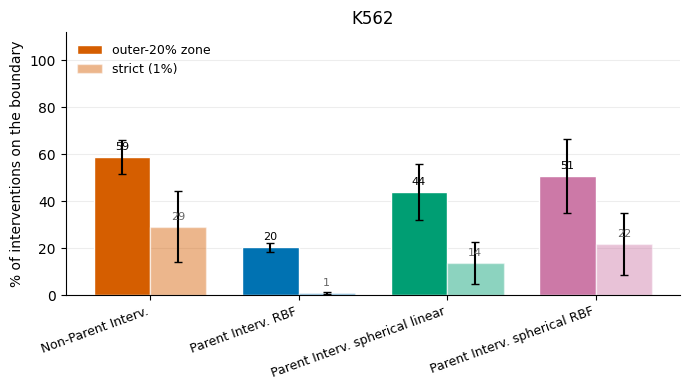

In [33]:
fig, axes = plt.subplots(1, len(GRAPHS), figsize=(7, 4), sharey=True, squeeze=False)
x = np.arange(len(VARIANTS)); w = 0.38

for ax, g in zip(axes[0], GRAPHS):
    sub = summary[summary.graph == g].set_index("variant").reindex(VARIANTS)
    ax.bar(x - w/2, sub.outer20_pct, w, yerr=sub.outer20_sd, capsize=3,
           label="outer-20% zone", color=[COLORS[v] for v in VARIANTS], edgecolor="white")
    ax.bar(x + w/2, sub.strict_bnd_pct, w, yerr=sub.strict_sd, capsize=3,
           label="strict (1%)", color=[COLORS[v] for v in VARIANTS],
           edgecolor="white", alpha=0.45)
    for xi, (a, b) in enumerate(zip(sub.outer20_pct, sub.strict_bnd_pct)):
        ax.text(xi - w/2, a + 3, f"{a:.0f}", ha="center", fontsize=8)
        ax.text(xi + w/2, b + 3, f"{b:.0f}", ha="center", fontsize=8, color="0.4")
    ax.set_xticks(x); ax.set_xticklabels(list(VARIANTS), rotation=20, ha="right", fontsize=9)
    ax.set_title("K562"); ax.set_ylim(0, 112)
    ax.spines[["top", "right"]].set_visible(False); ax.grid(axis="y", color="0.93")
    ax.set_axisbelow(True)

axes[0][0].set_ylabel("% of interventions on the boundary")
axes[0][0].legend(frameon=False, fontsize=9, loc="upper left")
fig.tight_layout(); plt.show()

## Boundary fraction per iteration

Left: cumulative fraction on the boundary (mean over seeds, band = +-sd). Right: per-iteration fraction of the intervened dimensions on the boundary.


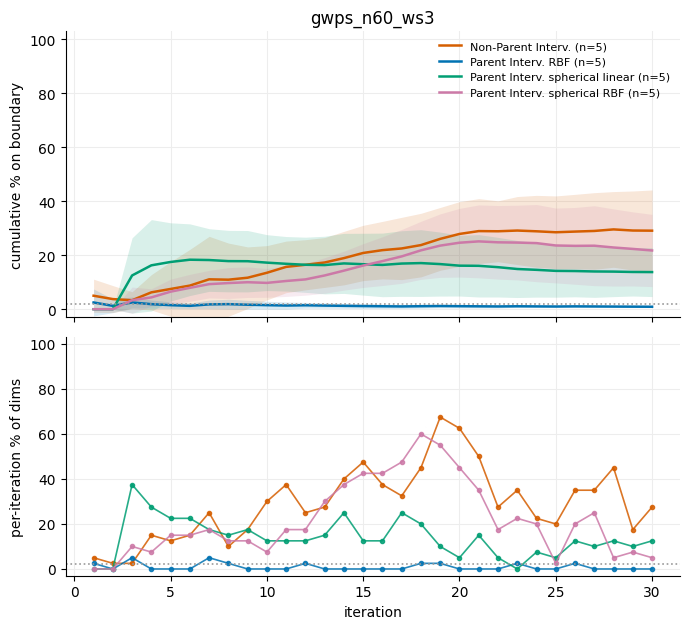

In [34]:
fig, axes = plt.subplots(2, len(GRAPHS), figsize=(7, 6.4), squeeze=False,
                         sharex=True, gridspec_kw={"height_ratios": [1.2, 1]})

for col, g in enumerate(GRAPHS):
    ax_cum, ax_it = axes[0][col], axes[1][col]
    for v in VARIANTS:
        runs = RUNS[(v, g)]
        if not runs:
            continue
        M = np.vstack([np.asarray(r["Boundary_Percentage"], float) for _, r in runs])
        t = np.arange(1, M.shape[1] + 1)
        cum = 100 * np.cumsum(M, axis=1) / t
        mu, sd = cum.mean(0), cum.std(0)
        ax_cum.plot(t, mu, color=COLORS[v], lw=1.8, label=f"{v} (n={len(runs)})")
        if len(runs) > 1:
            ax_cum.fill_between(t, mu - sd, mu + sd, color=COLORS[v], alpha=0.15, lw=0)
        ax_it.plot(t, 100 * M.mean(0), color=COLORS[v], lw=1.2, marker="o", ms=3, alpha=0.85)

    eps = next(r["Epsilon_Fraction"] for _, r in
               next(rs for rs in (RUNS[(v, g)] for v in VARIANTS) if rs))
    for ax in (ax_cum, ax_it):
        ax.axhline(100 * 2 * eps, color="0.6", ls=":", lw=1.2)
        ax.spines[["top", "right"]].set_visible(False)
        ax.grid(color="0.93"); ax.set_axisbelow(True)
    ax_cum.set_title(g); ax_cum.set_ylim(-3, 103); ax_it.set_ylim(-3, 103)
    ax_it.set_xlabel("iteration")

axes[0][0].set_ylabel("cumulative % on boundary")
axes[1][0].set_ylabel("per-iteration % of dims")
axes[0][0].legend(frameon=False, fontsize=8)
fig.tight_layout(); plt.show()

## Where the interventions land

All 5 replicate seeds pooled.


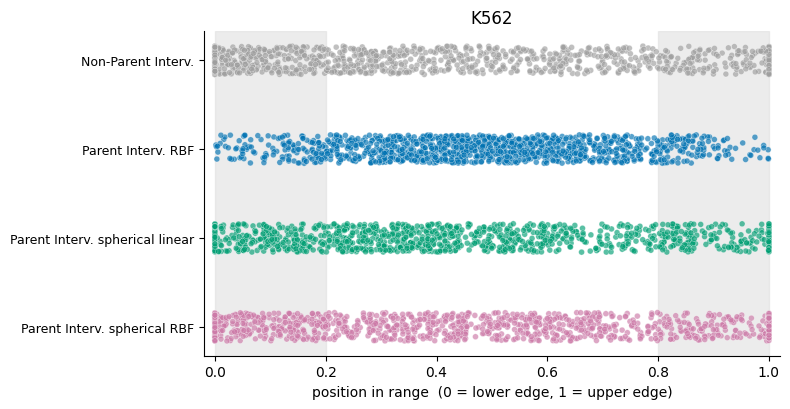

In [35]:
fig, axes = plt.subplots(1, len(GRAPHS), figsize=(8, 4.2), sharey=True, squeeze=False)
rng_j = np.random.default_rng(0)
ORDER = list(VARIANTS)[::-1]          # reversed row order

for ax, g in zip(axes[0], GRAPHS):
    for lo, hi in [(0, EDGE), (1 - EDGE, 1)]:
        ax.axvspan(lo, hi, color="0.88", alpha=0.6, zorder=0)
    for yi, v in enumerate(ORDER):
        runs = RUNS[(v, g)]
        if not runs:
            continue
        d = pd.concat([per_intervention(r) for _, r in runs], ignore_index=True)
        y = yi + rng_j.uniform(-0.16, 0.16, len(d))
        ax.scatter(d.pos, y, s=18, zorder=3, edgecolor="white", linewidth=0.3, alpha=0.65,
                   c=[COLORS[v] if p else "0.62" for p in d.is_parent])
    ax.set_yticks(range(len(ORDER)))
    ax.set_yticklabels(ORDER, fontsize=9)
    ax.set_xlim(-0.02, 1.02); ax.set_title("K562")
    ax.set_xlabel("position in range  (0 = lower edge, 1 = upper edge)")
    ax.spines[["top", "right"]].set_visible(False)

fig.tight_layout(); plt.show()

## Best interventions


In [36]:
rows = []
for (v, g), runs in RUNS.items():
    for run, r in runs:
        best = np.asarray(r["Best_Y"], float)
        per  = np.asarray(r["Per_trial_Y"], float)
        i    = int(np.argmin(per))
        vs, vals = r["Intervention_Set"][i], r["Intervention_Value"][i]
        poss = []
        for var, val in zip(vs, vals):
            lo, hi = r["Intervention_Ranges"][var]
            poss.append((var, float(val), (float(val) - lo) / (hi - lo)))
        var, val, pos = min(poss, key=lambda z: min(z[2], 1 - z[2]))  # dim closest to an edge
        rows.append(dict(
            variant=v, graph=g, run=run,
            best_Y=best[-1], improvement=best[-1] - best[0],
            best_trial=i, arity=len(vs),
            edge_var=var, is_parent=var in set(r["True_Parents"]),
            gene=r.get("Index_To_ENSG", {}).get(int(var), ""),
            edge_value=val, edge_pos=pos,
        ))

best_tbl = pd.DataFrame(rows)
best_agg = (best_tbl.groupby(["variant", "graph"])
            .agg(n=("run", "size"), best_Y_mean=("best_Y", "mean"),
                 best_Y_sd=("best_Y", lambda s: s.std(ddof=0)),
                 improvement_mean=("improvement", "mean"),
                 improvement_sd=("improvement", lambda s: s.std(ddof=0)),
                 edge_pos_mean=("edge_pos", "mean"))
            .reset_index())
best_agg.round(3)

,variant,graph,n,best_Y_mean,best_Y_sd,improvement_mean,improvement_sd,edge_pos_mean
0,Non-Parent Interv.,gwps_n60_ws3,5,-8.419,4.281,-5.186,2.817,0.000
1,Parent Interv. RBF,gwps_n60_ws3,5,-7.266,1.123,-5.899,1.626,0.201
2,Parent Interv. spherical RBF,gwps_n60_ws3,5,-18.259,5.534,-23.582,9.684,0.170
3,Parent Interv. spherical linear,gwps_n60_ws3,5,-15.350,2.159,-20.673,5.981,0.371


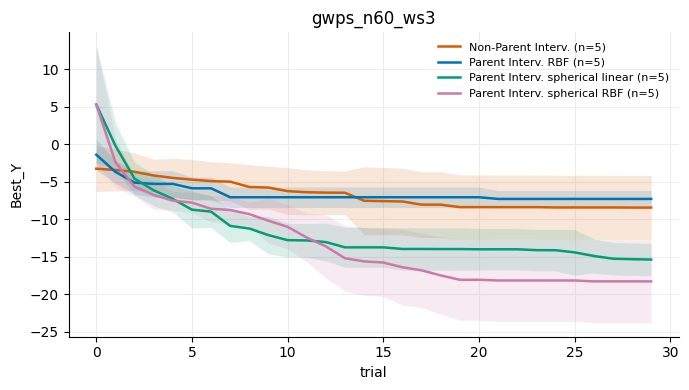

In [37]:
fig, axes = plt.subplots(1, len(GRAPHS), figsize=(7, 4), squeeze=False)

for ax, g in zip(axes[0], GRAPHS):
    for v in VARIANTS:
        runs = RUNS[(v, g)]
        if not runs:
            continue
        B = np.vstack([np.asarray(r["Best_Y"], float) for _, r in runs])
        t = np.arange(B.shape[1])
        mu, sd = B.mean(0), B.std(0)
        ax.plot(t, mu, color=COLORS[v], lw=1.8, label=f"{v} (n={len(runs)})")
        if len(runs) > 1:
            ax.fill_between(t, mu - sd, mu + sd, color=COLORS[v], alpha=0.15, lw=0)
    ax.set_title(g); ax.set_xlabel("trial"); ax.set_ylabel("Best_Y")
    ax.spines[["top", "right"]].set_visible(False); ax.grid(color="0.93")
    ax.set_axisbelow(True)

axes[0][0].legend(frameon=False, fontsize=8)
fig.tight_layout(); plt.show()

## Random sets: association vs boundary

The `random` runs record each chosen non-parent's observational correlation with the target. If boundary-seeking tracks observational association rather than causal effect, edge occupancy should rise with |corr| even though none of these nodes is a parent.


,graph,run,chosen,mean_abs_corr,max_abs_corr,outer20_pct,improvement
0,gwps_n60_ws3,1,"(12, 21, 23, 27, 28, 37, 42, 46)",0.178,0.344,57.083,-3.508
1,gwps_n60_ws3,2,"(0, 3, 5, 12, 20, 31, 42, 46)",0.190,0.454,73.333,-7.284
2,gwps_n60_ws3,3,"(1, 15, 16, 25, 41, 52, 56, 59)",0.130,0.196,55.417,-2.905
3,gwps_n60_ws3,4,"(8, 19, 27, 38, 39, 43, 45, 46)",0.296,0.529,53.333,-2.544
4,gwps_n60_ws3,5,"(7, 9, 19, 33, 37, 39, 52, 55)",0.131,0.233,55.000,-9.690


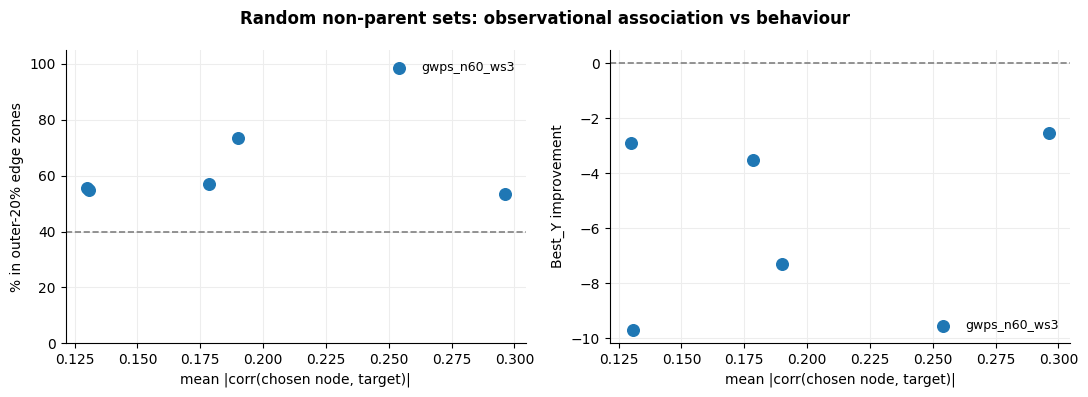

In [38]:
rows = []
for (v, g), runs in RUNS.items():
    for run, r in runs:
        corr = r.get("Chosen_Corr_With_Target")
        if not corr:                      # only the random runs carry this
            continue
        d = per_intervention(r)
        rows.append(dict(
            graph=g, run=run, chosen=tuple(r["Random_Set"]),
            mean_abs_corr=float(np.mean([abs(c) for c in corr.values()])),
            max_abs_corr=float(np.max([abs(c) for c in corr.values()])),
            outer20_pct=100 * float(((d.pos <= EDGE) | (d.pos >= 1 - EDGE)).mean()),
            improvement=float(np.asarray(r["Best_Y"], float)[-1]
                              - np.asarray(r["Best_Y"], float)[0]),
        ))

rand_tbl = pd.DataFrame(rows)
if rand_tbl.empty:
    print("no random-set runs found")
else:
    display(rand_tbl.round(3))
    fig, axes = plt.subplots(1, 2, figsize=(11, 4))
    mk = {g: m for g, m in zip(GRAPHS, ["o", "s", "^", "D"])}
    for g, sub in rand_tbl.groupby("graph"):
        axes[0].scatter(sub.mean_abs_corr, sub.outer20_pct, s=70, marker=mk[g], label=g)
        axes[1].scatter(sub.mean_abs_corr, sub.improvement, s=70, marker=mk[g], label=g)
    axes[0].axhline(40, color="0.5", ls="--", lw=1.2)
    axes[0].set_ylabel("% in outer-20% edge zones"); axes[0].set_ylim(0, 105)
    axes[1].axhline(0, color="0.5", ls="--", lw=1.2)
    axes[1].set_ylabel("Best_Y improvement")
    for ax in axes:
        ax.set_xlabel("mean |corr(chosen node, target)|")
        ax.spines[["top", "right"]].set_visible(False)
        ax.grid(color="0.93"); ax.set_axisbelow(True); ax.legend(frameon=False, fontsize=9)
    fig.suptitle("Random non-parent sets: observational association vs behaviour",
                 fontsize=12, fontweight="bold")
    fig.tight_layout(); plt.show()